## Memory Basics


```txt
Memory Address: [1000] [1001] [1002] [1003] [1004] [1005] [1006] ...
Content:        [    ] [    ] [    ] [    ] [    ] [    ] [    ] ...
```


In [ ]:
arr = [10,20,30,40]

```txt
Memory Address: [1000-1003] [1004-1007] [1008-1011] [1012-1015] [1016-1019]
Array Index:    [    0    ] [    1    ] [    2    ] [    3    ] [    4    ]
Value:          [   10    ] [   20    ] [   30    ] [   40    ] [   50    ]
```


**where and how are index values are stored?**

Answer is indexes are never stored they are being calcuated using metadata like initial address with concept of how much each elements consuems RAM.

```txt
Element_Address = Base_Address + (Index × Element_Size)

Example: arr[3] = 1000 + (3 × 4) = 1012
```

In [ ]:
# What you write:
value = arr[3]

# What actually happens:
# 1. Get base address: 1000
# 2. Calculate offset: 3 × 4 bytes = 12
# 3. Go to address: 1000 + 12 = 1012
# 4. Read 4 bytes starting at 1012

[AhA]
Since index caluclation is run time and mathematical, accessing the value is $O(1)$ time complexity

### static array view

```txt
Stack Memory:
┌─────────────┐
│ arr[0]: 10  │ ← Base address
│ arr[1]: 20  │
│ arr[2]: 30  │
│ arr[3]: 40  │
│ arr[4]: 50  │
└─────────────┘
Size: 5 (fixed)
```

### dynamic array view

```txt
List Object:              Actual Array (at address 1000):
┌─────────────┐          ┌────┬────┬────┬────┬────┬────┬────┬────┐
│ metadata    │          │ 10 │ 20 │ 30 │ 40 │ 50 │    │    │    │
│ items: 1000 ├─────────→└────┴────┴────┴────┴────┴────┴────┴────┘
│ size: 5     │           0    1    2    3    4    5    6    7
│ capacity: 8 │           (indices calculated, not stored!)
└─────────────┘
```

Formally

**ARRAY** : An array is a contiguous block of memory that stores elements of the same data type, accessed through zero-based indexing.

**List** :  A list is a more abstract data structure that may or may not use contiguous memory but provides similar sequential access to elements.

---

Practically

Think of an array like a row of mailboxes in an apartment building - each box has a number (index), they're all the same size, and they're arranged in a straight line. You can quickly go to mailbox #5 if you know where mailbox #0 is. Lists are similar but might be more flexible, like a chain of connected storage units that can grow or shrink.

## Concept Pattern

core purpose :
- Storing multiple related items in a single, organized structure
- Providing quick access to elements by position (index)
- Enabling iteration over collections of data
- Representing sequences, collections, or ordered data

Collateral uses: Implementing other data structures (stacks, queues, hash tables)
Building blocks for matrices, strings, and more complex structures.


## Static array Implementation

In [ ]:
class Array:
    def __init__(self, capacity, default_value=None):
        # Step 1: Store the capacity (fixed size)
        # Step 2: Create internal storage using Python list
        # Step 3: Initialize all elements with default_value
        # Hint: Use list comprehension or [default_value] * capacity
        self.capacity = capacity
        self._data = [default_value] * capacity

    def get(self, index):
        # Step 1: Check if index is valid (0 <= index < capacity)
        # Step 2: If invalid, raise IndexError with helpful message
        # Step 3: Return the element at self._data[index]
        # Hint: This simulates memory[base_address + index * element_size]
        if self.index >=0 and < self.capacity:
          return self._data[index]
        else:
          raise IndexError("out of index")

    def set(self, index, value):
        # Step 1: Check if index is valid (0 <= index < capacity)
        # Step 2: If invalid, raise IndexError
        # Step 3: Set self._data[index] = value
        # Hint: This simulates writing to calculated memory address
        pass

    def traverse(self):
        # Step 1: Iterate through all elements
        # Step 2: Yield each element (makes this a generator)
        # Hint: Use 'for i in range(self.capacity)' or iterate self._data
        pass

    def __repr__(self):
        # Step 1: Create readable string representation
        # Step 2: Show capacity and current contents
        # Hint: Format as "Array(capacity=X, data=[...])"
        pass

In [ ]:
class Array:
    def __init__(self, capacity, default_value=None):
        self.capacity = capacity
        self._data = [default_value] * capacity

    def get(self, index):
        if index >=0 and index < self.capacity:
          return self._data[index]
        else:
          raise IndexError("out of index")

    def set(self, index, value):
        if index >=0 and index < self.capacity:
          self._data[index] = value
        else:
          raise IndexError("out of index")

    def traverse(self):
        return iter(self._data)

    def __repr__(self):
        """String representation for debugging - what you see when you print()"""
        return f"Array(capacity={self.capacity}, data={self._data})"

In [ ]:
## more natural implementation

class Array:
    def __init__(self, *args):
        """
        Initialize array with:
        - Array(5) -> capacity 5, all None
        - Array(1, 2, 3, 4) -> array with these values
        - Array([1, 2, 3]) -> from a list
        """
        if len(args) == 1:
            if isinstance(args[0], int):
                # Array(5) - create with capacity
                self.capacity = args[0]
                self._data = [None] * self.capacity
            elif isinstance(args[0], list):
                # Array([1, 2, 3]) - from list
                self._data = args[0].copy()
                self.capacity = len(self._data)
            else:
                # Array(single_value) - array with one element
                self._data = [args[0]] # what happens when I do [*args[0]]?
                self.capacity = 1
        else:
            # Array(1, 2, 3, 4) - multiple values
            self._data = list(args)
            self.capacity = len(self._data)

    def get(self, index):
        if 0 <= index < self.capacity:
            return self._data[index]
        else:
            raise IndexError(f"Index {index} out of range [0, {self.capacity-1}]")

    def set(self, index, value):
        if 0 <= index < self.capacity:
            self._data[index] = value
        else:
            raise IndexError(f"Index {index} out of range [0, {self.capacity-1}]")

    def __getitem__(self, index):
        """Allow arr[index] syntax"""
        return self.get(index)

    def __setitem__(self, index, value):
        """Allow arr[index] = value syntax"""
        self.set(index, value)

    def __len__(self):
        """Allow len(arr)"""
        return self.capacity

    def __iter__(self):
        """Allow for item in arr:"""
        return iter(self._data)

    def __repr__(self):
        """Pretty print the array"""
        return f"Array({', '.join(map(str, self._data))})"

    def __str__(self):
        """String representation"""
        return f"[{', '.join(map(str, self._data))}]"

    def __eq__(self, other):
        """Allow arr1 == arr2 comparison"""
        if isinstance(other, Array):
            return self._data == other._data
        elif isinstance(other, list):
            return self._data == other
        return False

    def __contains__(self, value):
        """Allow 'value in arr' syntax"""
        return value in self._data

In [ ]:
## usage
# Different ways to create arrays
arr1 = Array(1, 2, 3, 4)        # Multiple arguments
arr2 = Array([10, 20, 30])      # From list
arr3 = Array(5)                 # Empty array with capacity 5
arr4 = Array("hello")           # Single element array

print(arr1)  # [1, 2, 3, 4]
print(repr(arr1))  # Array(1, 2, 3, 4)

# Natural array operations
arr = Array(10, 20, 30, 40, 50)

# Indexing
print(arr[0])      # 10
arr[1] = 25        # Set value
print(arr[1])      # 25

# Length
print(len(arr))    # 5

# Iteration
for value in arr:
    print(value, end=" ")  # 10 25 30 40 50

# Membership test
print(30 in arr)   # True
print(100 in arr)  # False

# Equality
arr2 = Array(10, 25, 30, 40, 50)
print(arr == arr2)  # True
print(arr == [10, 25, 30, 40, 50])  # True

## Runtime view

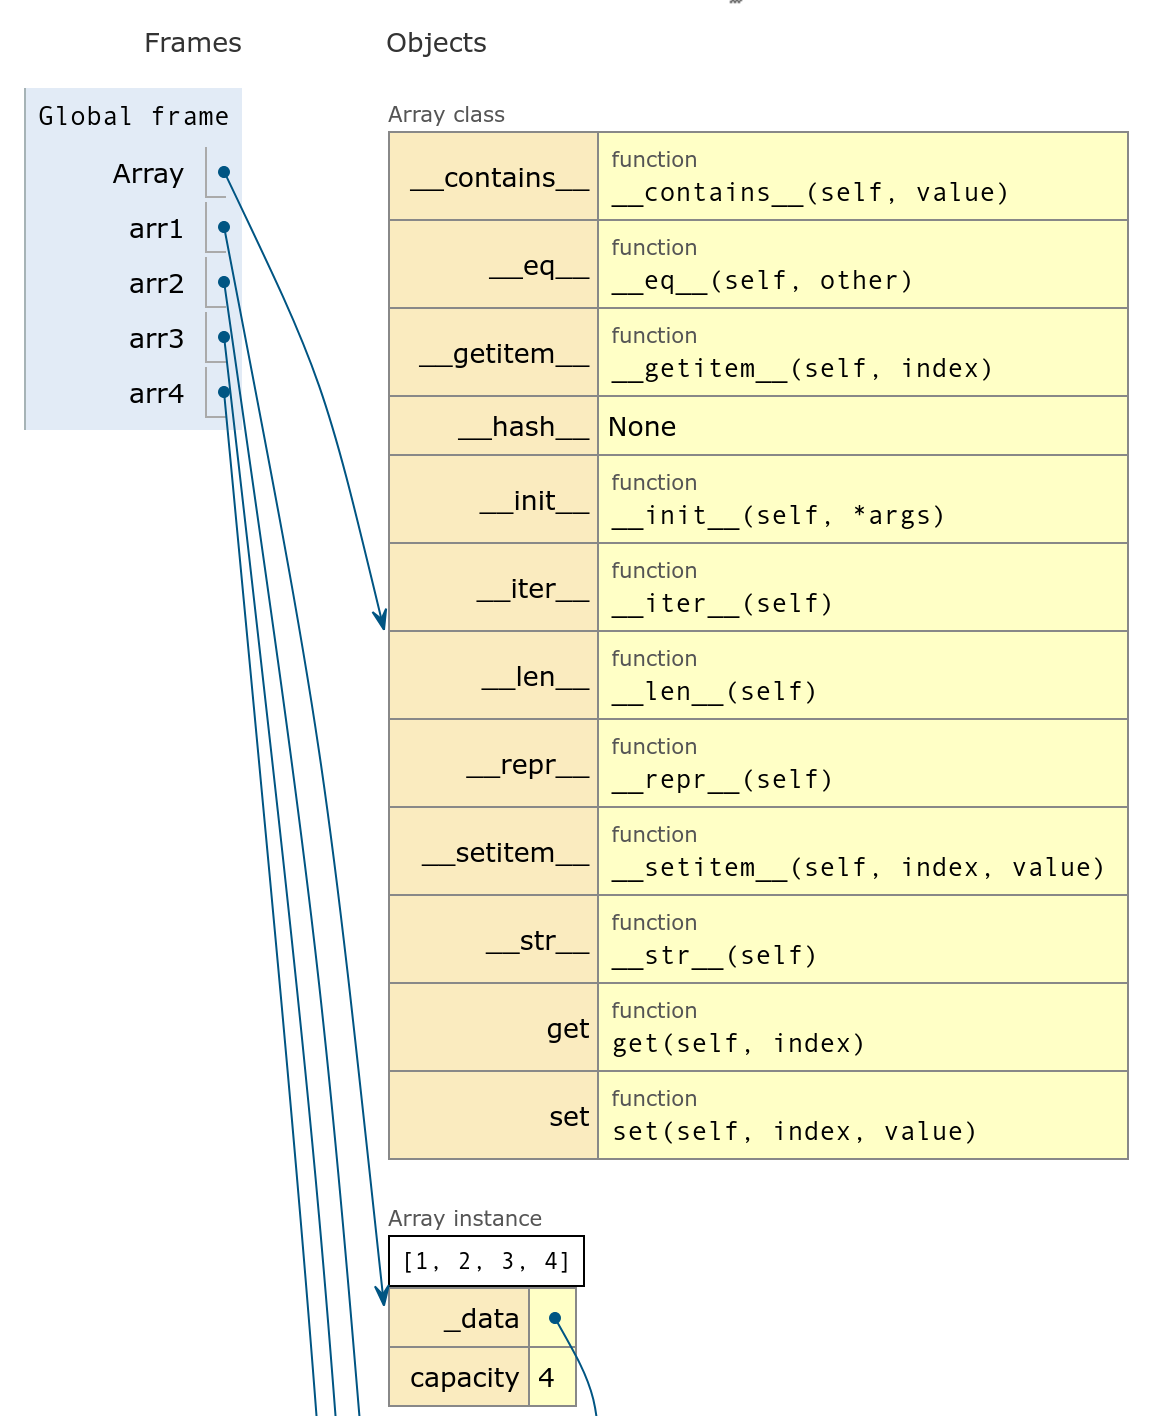

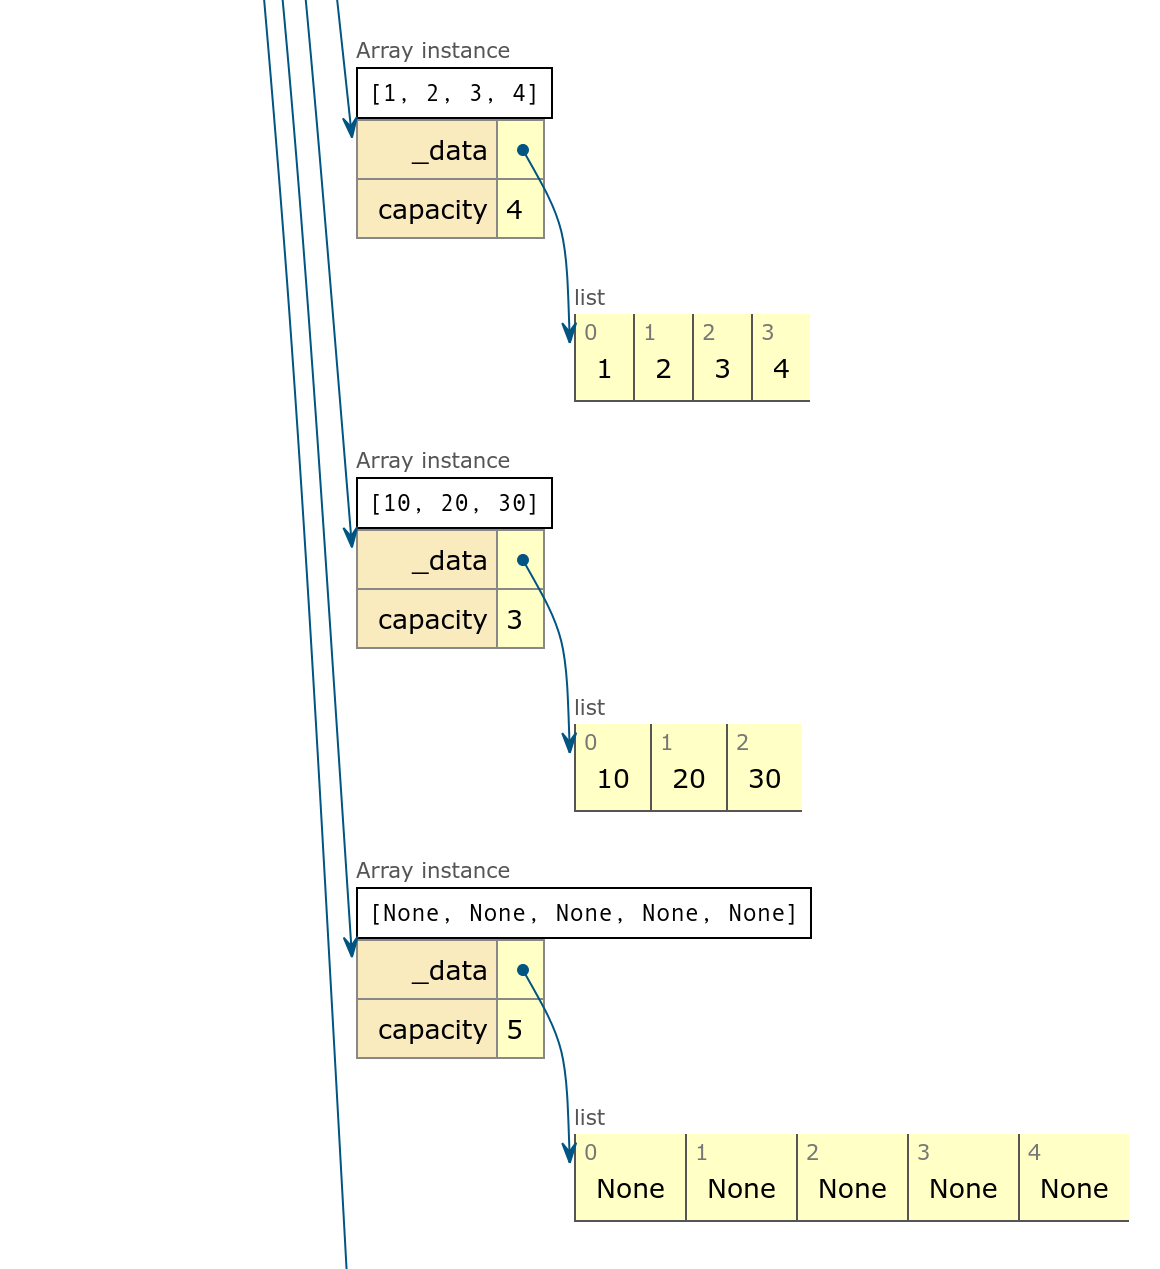

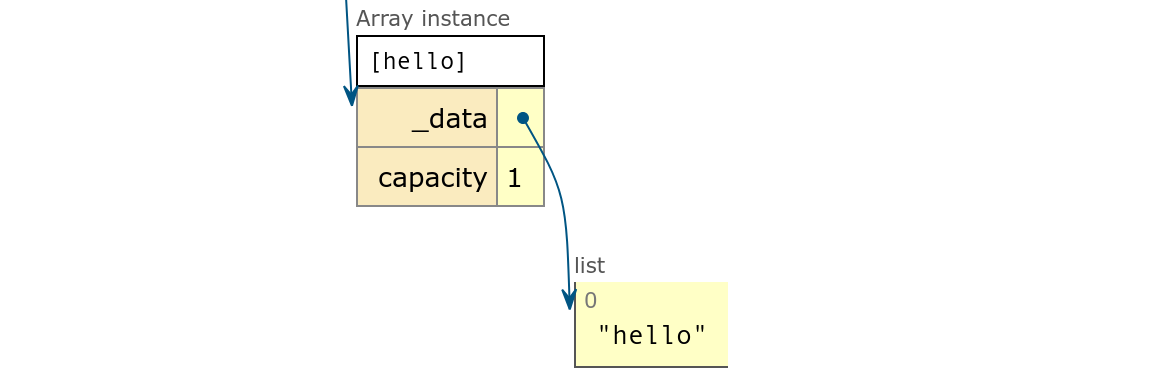

## Concept Visualization in Depth

https://www.kirupa.com/data_structures_algorithms/arrays_data_structure.htm

## Problem Solving Prerequisites

### terminilogies

1. Subarray - A range of contiguous values within an array.
  example : given an array `[2,3,6,1,5,4]` subarray = `[3,6,1]` but `[3,1,5]` isnt.
2. Subsequence - A sequence that can be derived from the given sequence by deleting some or no elements without changing the order of the remaining elements.
I have derived a sequence `[3,1,5]` didnt delete and kept order same so, this is a sub sequence. `[3,5,1]` isnt sub array.